# Analyzing DeFi Transactions & Wallet Activity Tracking
### A Comprehensive Python Class

---

## What We Will Cover

| Section | Topic |
|---------|-------|
| 1 | Setup & Connections |
| 2 | Wallet Profiling — ETH & Token Balances |
| 3 | Transaction History Analysis |
| 4 | Decoding ERC-20 Transfer Events |
| 5 | Uniswap Swap Detection |
| 6 | Aave Lending / Borrowing Activity |
| 7 | Gas Usage Analytics |
| 8 | Portfolio Visualization |
| 9 | Wallet Behavior Scoring (DeFi Power-User Index) |

---

### Prerequisites
- You completed the **web3py** introductory notebook  
- You have an **Infura** (or Alchemy) RPC URL in your `.env` file  
- Libraries: `web3`, `pandas`, `matplotlib`, `seaborn`, `python-dotenv`, `requests`

---
## Section 1 — Setup & Connections

We start by loading our environment variables and connecting to Ethereum mainnet.  
**Always** store API keys in `.env` — never hard-code them.

In [1]:
# ── Install dependencies (run once) ──────────────────────────────────────────
# ! pip install web3 pandas matplotlib seaborn python-dotenv requests

In [2]:
import os
import json
import time
import requests
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from web3 import Web3
from dotenv import load_dotenv

# ── Load secrets ──────────────────────────────────────────────────────────────
load_dotenv()
INFURA_URL  = os.getenv("INFURA_URL")   # e.g. https://mainnet.infura.io/v3/YOUR_KEY
ETHERSCAN_KEY = os.getenv("ETHERSCAN_API_KEY", "")  # optional, for tx history

# ── Connect ───────────────────────────────────────────────────────────────────
w3 = Web3(Web3.HTTPProvider(INFURA_URL))
assert w3.is_connected(), "Connection failed — check your INFURA_URL"
print(f"Connected  |  Latest block: {w3.eth.block_number:,}")

Connected  |  Latest block: 24,886,152


### Shared Utilities

Small helper functions we will reuse throughout the notebook.

In [3]:
def to_checksum(address: str) -> str:
    """Ensure an Ethereum address is EIP-55 checksummed."""
    return Web3.to_checksum_address(address.lower())

def from_wei(value: int, decimals: int = 18) -> float:
    """Convert a raw token integer to a human-readable float."""
    return value / (10 ** decimals)

def wei_to_eth(wei: int) -> float:
    return float(w3.from_wei(wei, 'ether'))


print("Utilities loaded.")

Utilities loaded.


---
## Section 2 — Wallet Profiling: ETH & Token Balances

The first thing we do when analysing a wallet is build a **snapshot** of what it holds right now.

In [4]:
# ── Minimal ERC-20 ABI (only the functions we need) ───────────────────────────
ERC20_ABI = [
    {   "constant": True, 
        "inputs": [{"name": "_owner", "type": "address"}],
        "name": "balanceOf", 
        "outputs": [{"name": "balance", "type": "uint256"}],
        "stateMutability": "view",
        "type": "function"
    },
    {   "constant": True, 
        "inputs": [], 
        "name": "decimals",
        "outputs": [{"name": "", "type": "uint8"}],
        "stateMutability": "view",
        "type": "function"
    },
    {   "constant": True, 
        "inputs": [], 
        "name": "symbol",
        "outputs": [{"name": "", "type": "string"}],
        "stateMutability": "view",
        "type": "function"
    },
    {   "constant": True,  
        "inputs": [], 
        "name": "totalSupply",
        "outputs": [{"name": "", "type": "uint256"}],
        "stateMutability": "view", 
        "type": "function"
    },
]

In [5]:
# ── Well-known mainnet token addresses ────────────────────────────────────────
TOKENS = {
    "USDC" : "0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48",
    "USDT" : "0xdAC17F958D2ee523a2206206994597C13D831ec7",
    "WETH" : "0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2",
    "DAI"  : "0x6B175474E89094C44Da98b954EedeAC495271d0F",
    "LINK" : "0x514910771AF9Ca656af840dff83E8264EcF986CA",
    "UNI"  : "0x1f9840a85d5aF5bf1D1762F925BDADdC4201F984",
    "AAVE" : "0x7Fc66500c84A76Ad7e9c93437bFc5Ac33E2DDaE9",
}

In [6]:
def get_token_balance(wallet: str, token_address: str) -> dict:
    """
    Fetch the balance of a single ERC-20 token for a wallet.
    Returns a dict with symbol, raw balance, decimals, and normalised balance.
    """
    contract = w3.eth.contract(address=to_checksum(token_address), abi=ERC20_ABI)
    try:
        raw      = contract.functions.balanceOf(to_checksum(wallet)).call()
        decimals = contract.functions.decimals().call()
        symbol   = contract.functions.symbol().call()
        return {"symbol": symbol, "raw": raw, "decimals": decimals,
                "balance": from_wei(raw, decimals)}
    except Exception as e:
        return {"symbol": "?", "raw": 0, "decimals": 18, "balance": 0.0, "error": str(e)}


def wallet_snapshot(wallet: str, tokens: dict = TOKENS) -> pd.DataFrame:
    """
    Return a DataFrame with the ETH + token portfolio of a wallet.
    """
    wallet = to_checksum(wallet)
    rows = []

    # ETH
    eth_wei = w3.eth.get_balance(wallet)
    rows.append({"asset": "ETH", "balance": wei_to_eth(eth_wei), "address": "native"})

    # ERC-20 tokens
    for name, addr in tokens.items():
        info = get_token_balance(wallet, addr)
        rows.append({"asset": info["symbol"] or name,
                     "balance": info["balance"],
                     "address": addr})

    df = pd.DataFrame(rows)
    df = df[df["balance"] > 0].reset_index(drop=True)   # only show non-zero
    return df

In [7]:
# ── Try it on a real DeFi whale (Binance hot-wallet) ─────────────────────────
WHALE = "0xe1940f578743367F38D3f25c2D2d32D6636929B6"

snapshot = wallet_snapshot(WHALE)
print(f"Portfolio for {WHALE}\n")
print(snapshot.to_string(index=False))

Portfolio for 0xe1940f578743367F38D3f25c2D2d32D6636929B6

asset      balance                                    address
  ETH 1.000000e-06                                     native
 USDC 1.700000e+09 0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48


### Exercise 2.1
> Pick any public wallet address (e.g. a friend's, a protocol treasury, or one from Etherscan)  
> and call `wallet_snapshot()` on it. What tokens do you see?

In [8]:
MY_WALLET = "0xE1fC7834857Ece72e1CBaaa227Cf038AE9168267"  # replace with any address
wallet_snapshot(MY_WALLET)

,asset,balance,address
0,ETH,3.626956e+02,native
1,WETH,1.000000e-07,0xC02aaA39b223FE8D0A0e5C4F27eAD9083C756Cc2


---
## Section 3 — Transaction History Analysis

The **Etherscan API** gives us a wallet's full transaction history without scanning every block manually.  
This is how most blockchain analytics tools work behind the scenes.

> **Note:** The free Etherscan API tier allows 5 req/sec and 100,000 req/day.  
> If you don't have a key, the demo uses a public endpoint (slower but works).

In [9]:
ETHERSCAN_BASE = "https://api.etherscan.io/v2/api"

def fetch_tx_history(wallet: str, max_records: int = 200) -> pd.DataFrame:
    """
    Pull normal (ETH) transactions for a wallet from Etherscan.
    Returns a cleaned DataFrame.
    """
    params = {
        "chainid"   : 1,  # Ethereum mainnet
        "module"  : "account",
        "action"  : "txlist",
        "address" : wallet,
        "startblock": 0,
        "endblock"  : 99999999,
        "sort"      : "desc",
        "offset"    : max_records,
        "page"      : 1,
        "apikey"    : ETHERSCAN_KEY,
    }
    r = requests.get(ETHERSCAN_BASE, params=params, timeout=15)
    r.raise_for_status()
    data = r.json()

    if data["status"] != "1":
        print(f"Etherscan response: {data['message']}")
        return pd.DataFrame()

    df = pd.DataFrame(data["result"])

    # ── Clean & type-cast ────────────────────────────────────────────────────
    df["timestamp"]    = pd.to_datetime(df["timeStamp"].astype(int), unit="s")
    df["value_eth"]    = df["value"].astype(float).apply(lambda x: x / 1e18)
    df["gas_price_gwei"] = df["gasPrice"].astype(float).apply(lambda x: x / 1e9)
    df["gas_used"]     = df["gasUsed"].astype(int)
    df["gas_cost_eth"] = (df["gasPrice"].astype(float) * df["gasUsed"].astype(float)) / 1e18
    df["block"]        = df["blockNumber"].astype(int)
    df["is_error"]     = df["isError"].astype(int)
    df["direction"]    = df["from"].str.lower().apply(
                             lambda f: "out" if f == wallet.lower() else "in")

    keep = ["timestamp", "block", "hash", "from", "to",
            "value_eth", "gas_used", "gas_price_gwei", "gas_cost_eth",
            "direction", "is_error", "functionName"]
    return df[[c for c in keep if c in df.columns]].copy()

print("Function defined.")

Function defined.


In [10]:
# ── Fetch history (works with or without API key) ─────────────────────────────
STUDY_WALLET = "0x7B9eB6Dc28dE8b81189067f04458E2F723a0dB01"

tx_df = fetch_tx_history(STUDY_WALLET, max_records=200)
print(f"Fetched {len(tx_df)} transactions")
tx_df.head(5)

Fetched 35 transactions


,timestamp,block,hash,from,to,value_eth,gas_used,gas_price_gwei,gas_cost_eth,direction,is_error,functionName
0,2026-04-15 15:04:35,24885994,0x74bc6cd685528d8f63b5b582f162e9fb22bca04be0be...,0x7b9eb6dc28de8b81189067f04458e2f723a0db01,0x4cd00e387622c35bddb9b4c962c136462338bc31,0.001760,24824,0.655345,0.000016,out,0,
1,2026-04-15 14:54:11,24885942,0xae537d9e2c9042f7a4d61c8310fc8f21921d5712eef9...,0x7b9eb6dc28de8b81189067f04458e2f723a0db01,0x4cd00e387622c35bddb9b4c962c136462338bc31,0.001380,24824,0.323604,0.000008,out,0,
2,2026-04-15 14:51:35,24885929,0x6be516e9ec36eb8f6faed2a559a70233a15aebac1df2...,0x2cff890f0378a11913b6129b2e97417a2c302680,0x7b9eb6dc28de8b81189067f04458e2f723a0db01,0.001768,21000,0.099187,0.000002,in,0,
3,2026-04-14 13:42:59,24878403,0x0d28cb8325e60a2947b7f6dafd334a7c5b67e234bdeb...,0x7b9eb6dc28de8b81189067f04458e2f723a0db01,0xdac17f958d2ee523a2206206994597c13d831ec7,0.000000,41297,2.214537,0.000091,out,0,"transfer(address _to, uint256 _value)"
4,2026-04-13 18:14:47,24872578,0xfa6dc389579fd573a66c1645a1b3794a21b438822c93...,0x7b9eb6dc28de8b81189067f04458e2f723a0db01,0x0439e60f02a8900a951603950d8d4527f400c3f1,0.000000,111033,2.234902,0.000248,out,0,"bridge(string adapterId,address srcToken,uint2..."


In [11]:
# ── Quick summary statistics ───────────────────────────────────────────────────
if not tx_df.empty:
    outgoing = tx_df[tx_df["direction"] == "out"]
    incoming = tx_df[tx_df["direction"] == "in"]

    print("=" * 45)
    print(f" Total transactions   : {len(tx_df):>10,}")
    print(f" Outgoing             : {len(outgoing):>10,}")
    print(f" Incoming             : {len(incoming):>10,}")
    print(f" Failed txns          : {tx_df['is_error'].sum():>10,}")
    print(f" Total ETH sent       : {outgoing['value_eth'].sum():>10.4f} ETH")
    print(f" Total ETH received   : {incoming['value_eth'].sum():>10.4f} ETH")
    print(f" Total gas spent      : {outgoing['gas_cost_eth'].sum():>10.6f} ETH")
    print(f" Avg gas price        : {tx_df['gas_price_gwei'].mean():>10.2f} Gwei")
    print(f" Date range           : {tx_df['timestamp'].min().date()} → {tx_df['timestamp'].max().date()}")
    print("=" * 45)

 Total transactions   :         35
 Outgoing             :         27
 Incoming             :          8
 Failed txns          :          0
 Total ETH sent       :     0.0274 ETH
 Total ETH received   :     0.0269 ETH
 Total gas spent      :   0.004552 ETH
 Avg gas price        :       1.26 Gwei
 Date range           : 2026-04-04 → 2026-04-15


### 3.1 — Transaction Frequency Over Time

Understanding **when** a wallet is active can reveal a lot:  
- Bot wallets transact every block  
- Human traders transact in bursts  
- Institutional wallets are often active during business hours

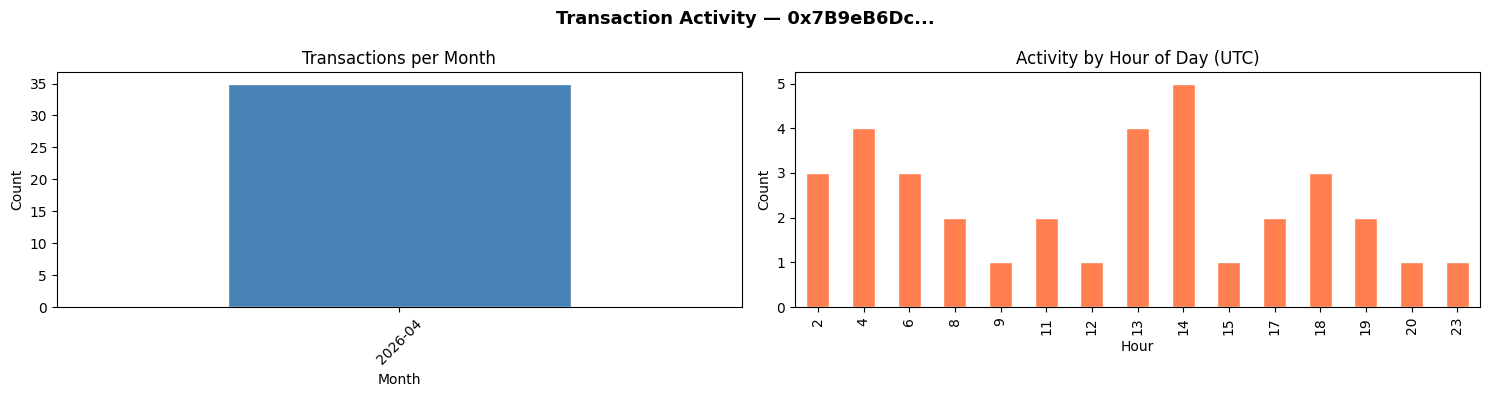

In [12]:
if not tx_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f"Transaction Activity — {STUDY_WALLET[:10]}...", fontsize=13, fontweight="bold")

    # ── Left: transactions per month ─────────────────────────────────────────
    monthly = tx_df.groupby(tx_df["timestamp"].dt.to_period("M")).size()
    monthly.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
    axes[0].set_title("Transactions per Month")
    axes[0].set_xlabel("Month")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=45)

    # ── Right: activity by hour of day (UTC) ─────────────────────────────────
    hourly = tx_df.groupby(tx_df["timestamp"].dt.hour).size()
    hourly.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
    axes[1].set_title("Activity by Hour of Day (UTC)")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

---
## Section 4 — Decoding ERC-20 Transfer Events

### How Event Logs Work

Every time an ERC-20 token is transferred, the contract emits a **log** entry:

```
Transfer(address indexed from, address indexed to, uint256 value)
```

The **topic[0]** is always the **keccak256 hash** of the event signature.  
Indexed parameters go into **topic[1]** and **topic[2]**.  
Non-indexed parameters (like `value`) are ABI-encoded in the `data` field.

```
topics[0]  =  keccak256("Transfer(address,address,uint256)")
topics[1]  =  from address  (32-byte padded)
topics[2]  =  to   address  (32-byte padded)
data       =  uint256 value (ABI-encoded)
```

In [13]:
# ── The canonical Transfer topic ──────────────────────────────────────────────
TRANSFER_TOPIC = w3.keccak(text="Transfer(address,address,uint256)").hex()
TRANSFER_TOPIC = "0x" + TRANSFER_TOPIC if not TRANSFER_TOPIC.startswith("0x") else TRANSFER_TOPIC
print(f"Transfer event topic: {TRANSFER_TOPIC}")

Transfer event topic: 0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef


In [14]:
def address_to_topic(address: str) -> str:
    """Pad a 20-byte address to a 32-byte log topic."""
    return Web3.to_hex(Web3.to_bytes(hexstr=address).rjust(32, b'\x00'))

def decode_transfer_log(log: dict, decimals: int = 18) -> dict:
    """
    Decode a single ERC-20 Transfer log entry into a readable dict.
    """
    topics = log["topics"]
    from_addr = Web3.to_checksum_address("0x" + topics[1].hex()[-40:])
    to_addr   = Web3.to_checksum_address("0x" + topics[2].hex()[-40:])
    raw_value = int(log["data"].hex(), 16)
    return {
        "tx_hash"   : log["transactionHash"].hex(),
        "block"     : log["blockNumber"],
        "token"     : log["address"],
        "from"      : from_addr,
        "to"        : to_addr,
        "raw_value" : raw_value,
        "value"     : from_wei(raw_value, decimals),
    }


def get_token_transfers(
    wallet: str,
    token_address: str,
    from_block: int = 0,
    to_block: int | str = "latest",
    direction: str = "both",   # "in", "out", or "both"
) -> pd.DataFrame:
    """
    Fetch all ERC-20 Transfer events involving `wallet` for `token_address`.
    Uses eth_getLogs — no third-party API required.
    """
    wallet = to_checksum(wallet)
    token  = to_checksum(token_address)

    # Retrieve symbol & decimals once
    contract = w3.eth.contract(address=token, abi=ERC20_ABI)
    try:
        decimals = contract.functions.decimals().call()
        symbol   = contract.functions.symbol().call()
    except Exception:
        decimals, symbol = 18, "???"

    wallet_topic = address_to_topic(wallet)

    logs_in, logs_out = [], []

    if direction in ("in", "both"):
        logs_in = w3.eth.get_logs({
            "fromBlock": from_block,
            "toBlock"  : to_block,
            "address"  : token,
            "topics"   : [TRANSFER_TOPIC, None, wallet_topic],
        })

    if direction in ("out", "both"):
        logs_out = w3.eth.get_logs({
            "fromBlock": from_block,
            "toBlock"  : to_block,
            "address"  : token,
            "topics"   : [TRANSFER_TOPIC, wallet_topic, None],
        })

    rows = []
    for log in logs_in:
        r = decode_transfer_log(log, decimals)
        r["symbol"] = symbol
        r["direction"] = "in"
        rows.append(r)
    for log in logs_out:
        r = decode_transfer_log(log, decimals)
        r["symbol"] = symbol
        r["direction"] = "out"
        rows.append(r)

    if not rows:
        print(f"No {symbol} transfers found in the specified block range.")
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values("block").reset_index(drop=True)
    return df

print("ERC-20 transfer decoder ready.")

ERC-20 transfer decoder ready.


In [15]:
# ── Concept check ─────────────────────────────────────────────────────────────
# Why do we search BOTH "in" and "out" separately?
#
#  eth_getLogs topics filter is positional:
#    topics[0] = event signature
#    topics[1] = from address  (indexed)
#    topics[2] = to   address  (indexed)
#
#  To find all transfers WHERE wallet is sender  → topics[1] = wallet
#  To find all transfers WHERE wallet is receiver → topics[2] = wallet
#  You cannot match either position in one query — you need two queries.

print("Concept understood. Now let's fetch some real data.")

Concept understood. Now let's fetch some real data.


In [16]:
# ── Demo: USDC transfers involving the Binance wallet (last ~50,000 blocks) ───
BINANCE = "0xe1940f578743367F38D3f25c2D2d32D6636929B6"
USDC    = TOKENS["USDC"]

latest     = w3.eth.block_number
from_block = latest - 5_000   # narrow range to avoid RPC timeout

print(f"Scanning blocks {from_block:,} → {latest:,} for USDC transfers...")
usdc_transfers = get_token_transfers(BINANCE, USDC, from_block=from_block)

if not usdc_transfers.empty:
    print(f"\nFound {len(usdc_transfers)} transfers")
    print(usdc_transfers[["block", "direction", "from", "to", "value", "symbol"]].head(10).to_string(index=False))

Scanning blocks 24,881,157 → 24,886,157 for USDC transfers...
No USDC transfers found in the specified block range.


---
## Section 5 — Uniswap Swap Detection

### How Uniswap V2 Works

Uniswap V2 is an **Automated Market Maker (AMM)**.  
Instead of order books, it uses **liquidity pools** — smart contracts that hold pairs of tokens.

When you swap Token A → Token B:
1. You call `swapExactTokensForTokens()` on the **Router** contract  
2. The router moves your tokens into the **Pair** contract  
3. The pair emits a `Swap` event  
4. The pair sends output tokens back to you

```
Swap(address indexed sender, uint amount0In, uint amount1In,
     uint amount0Out, uint amount1Out, address indexed to)
```

| Variable | Meaning |
|---|---|
| `amount0In` | Token0 deposited into the pool |
| `amount1Out` | Token1 withdrawn from the pool |
| `sender`    | Address that initiated the swap |
| `to`        | Address that received output tokens |

In [32]:
# ── Uniswap V2 Pair ABI (minimal — only the Swap event) ──────────────────────
UNI_V2_PAIR_ABI = [
    {
        "anonymous": False,
        "inputs": [
            {"indexed": True,  "name": "sender",     "type": "address"},
            {"indexed": False, "name": "amount0In",  "type": "uint256"},
            {"indexed": False, "name": "amount1In",  "type": "uint256"},
            {"indexed": False, "name": "amount0Out", "type": "uint256"},
            {"indexed": False, "name": "amount1Out", "type": "uint256"},
            {"indexed": True,  "name": "to",         "type": "address"},
        ],
        "name": "Swap",
        "type": "event",
    },
    {   "inputs": [],
        "name": "token0",
        "outputs": [{"type": "address"}], 
        "stateMutability": "view", 
        "type": "function"
    },
    {   "inputs": [], 
        "name": "token1", 
        "outputs": [{"type": "address"}], 
        "stateMutability": "view", 
        "type": "function"
    },
]

# ── Famous Uniswap V2 pairs ───────────────────────────────────────────────────
PAIRS = {
    "USDC/WETH" : "0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc",
    "DAI/WETH"  : "0xA478c2975Ab1Ea89e8196811F51A7B7Ade33eB11",
    "USDT/WETH" : "0x0d4a11d5EEaaC28EC3F61d100daF4d40471f1852",
}

In [18]:
SWAP_TOPIC = "0x" + w3.keccak(text="Swap(address,uint256,uint256,uint256,uint256,address)").hex()
print(f"Uniswap V2 Swap topic: {SWAP_TOPIC}")

Uniswap V2 Swap topic: 0xd78ad95fa46c994b6551d0da85fc275fe613ce37657fb8d5e3d130840159d822


In [19]:
def fetch_uniswap_swaps(pair_address: str, from_block: int, to_block: int | str = "latest") -> pd.DataFrame:
    """
    Fetch all Swap events from a Uniswap V2 pair contract.
    Returns a DataFrame with human-readable amounts.
    """
    pair = w3.eth.contract(address=to_checksum(pair_address), abi=UNI_V2_PAIR_ABI)

    # Identify the two tokens
    token0_addr = pair.functions.token0().call()
    token1_addr = pair.functions.token1().call()

    c0 = w3.eth.contract(address=token0_addr, abi=ERC20_ABI)
    c1 = w3.eth.contract(address=token1_addr, abi=ERC20_ABI)
    try:
        sym0, dec0 = c0.functions.symbol().call(), c0.functions.decimals().call()
        sym1, dec1 = c1.functions.symbol().call(), c1.functions.decimals().call()
    except Exception:
        sym0, dec0 = "T0", 18
        sym1, dec1 = "T1", 18

    logs = w3.eth.get_logs({
        "fromBlock": from_block,
        "toBlock"  : to_block,
        "address"  : to_checksum(pair_address),
        "topics"   : [SWAP_TOPIC],
    })

    rows = []
    for log in logs:
        topics = log["topics"]
        sender = Web3.to_checksum_address("0x" + topics[1].hex()[-40:])
        to_    = Web3.to_checksum_address("0x" + topics[2].hex()[-40:])

        # data = abi-encoded (amount0In, amount1In, amount0Out, amount1Out)
        data   = log["data"].hex() if hasattr(log["data"], "hex") else log["data"]
        # Each uint256 is 32 bytes = 64 hex chars
        chunks = [int(data[i:i+64], 16) for i in range(2, len(data), 64)]
        if len(chunks) < 4:
            continue
        a0in, a1in, a0out, a1out = chunks[:4]

        # Determine which token was sold and which was bought
        if a0in > 0:
            token_in, amt_in, token_out, amt_out = sym0, from_wei(a0in, dec0), sym1, from_wei(a1out, dec1)
        else:
            token_in, amt_in, token_out, amt_out = sym1, from_wei(a1in, dec1), sym0, from_wei(a0out, dec0)

        rows.append({
            "block"     : log["blockNumber"],
            "tx_hash"   : log["transactionHash"].hex(),
            "sender"    : sender,
            "recipient" : to_,
            "token_in"  : token_in,
            "amount_in" : amt_in,
            "token_out" : token_out,
            "amount_out": amt_out,
            "price"     : amt_in / amt_out if amt_out > 0 else None,
        })

    return pd.DataFrame(rows)


print("Uniswap V2 swap fetcher ready.")

Uniswap V2 swap fetcher ready.


In [20]:
# ── Fetch recent USDC/WETH swaps ──────────────────────────────────────────────
latest     = w3.eth.block_number
from_block = latest - 500          # last ~500 blocks ≈ ~100 minutes

pair_addr = PAIRS["USDC/WETH"]
print(f"Fetching swaps from USDC/WETH pair ({pair_addr})")
print(f"Blocks {from_block:,} → {latest:,}\n")

swaps = fetch_uniswap_swaps(pair_addr, from_block)
print(f"Found {len(swaps)} swaps")
if not swaps.empty:
    swaps.head(10)

Fetching swaps from USDC/WETH pair (0xB4e16d0168e52d35CaCD2c6185b44281Ec28C9Dc)
Blocks 24,885,657 → 24,886,157

Found 62 swaps


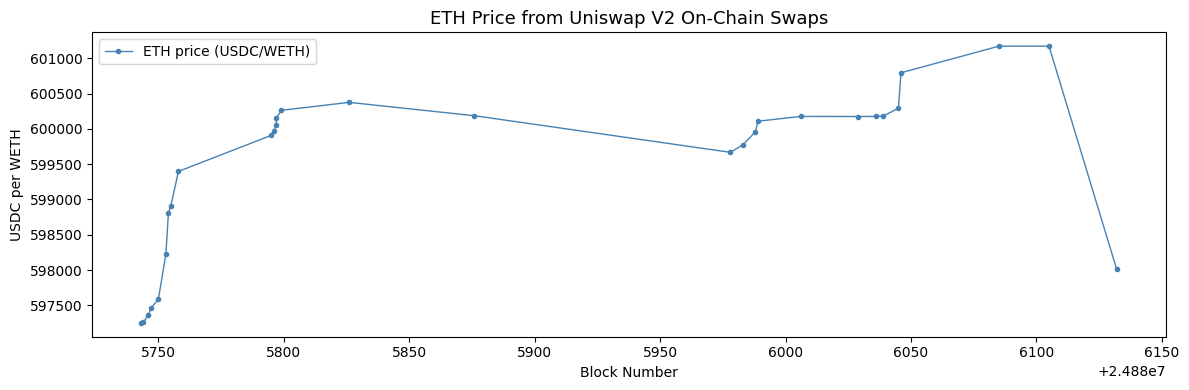

In [21]:
# ── Visualise price over the block range ─────────────────────────────────────
if not swaps.empty and "price" in swaps.columns:
    # Filter to USDC→WETH swaps to get ETH price in USD
    usdc_in = swaps[swaps["token_in"] == "USDC"].copy()

    if len(usdc_in) > 1:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(usdc_in["block"], usdc_in["price"], marker="o", markersize=3,
                linewidth=1, color="steelblue", label="ETH price (USDC/WETH)")
        ax.set_title("ETH Price from Uniswap V2 On-Chain Swaps", fontsize=13)
        ax.set_xlabel("Block Number")
        ax.set_ylabel("USDC per WETH")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough USDC→WETH swaps in range to plot price.")

### Exercise 5.1
> 1. Run the swap fetcher on the **DAI/WETH** pair.
> 2. Compare the implied ETH price from DAI/WETH vs USDC/WETH. Why might they differ?
> 3. Which addresses appear most frequently as `sender` in the swap logs?

In [22]:
# Your code here
dai_swaps = fetch_uniswap_swaps(PAIRS["DAI/WETH"], from_block)
dai_swaps.head()

,block,tx_hash,sender,recipient,token_in,amount_in,token_out,amount_out,price
0,24885703,e30680d9b25621f114471a83d4ec908f28de119b235466...,0x4c3ccC98C01103bE72bcfd29e1D2454c98d1A6e3,0x4c3ccC98C01103bE72bcfd29e1D2454c98d1A6e3,DAI,6.486372e+02,WETH,0.001086,597263.714571
1,24885746,a6bcc9d46e00768382d9735596e2124e6d293ab95c6487...,0x51C72848c68a965f66FA7a88855F9f7784502a7F,0x51C72848c68a965f66FA7a88855F9f7784502a7F,DAI,1.296285e+05,WETH,0.217012,597332.780854
2,24885746,bdcd57f967928c79a96b5d704c995ceedf2a45840e20d2...,0x278d858f05b94576C1E6f73285886876ff6eF8D2,0x278d858f05b94576C1E6f73285886876ff6eF8D2,DAI,1.774906e+05,WETH,0.297059,597491.807044
3,24885750,e10355bde2bbd54b2ce4bea9d4c5f88d887d6a7050aae3...,0xBdb3ba9ffe392549E1f8658DD2630c141fDF47B6,0xBdb3ba9ffe392549E1f8658DD2630c141fDF47B6,DAI,9.245576e+04,WETH,0.154703,597632.756951
4,24885753,794b066eb67553963912181949e9a8e7daa2750c54c3cd...,0x51C72848c68a965f66FA7a88855F9f7784502a7F,0x51C72848c68a965f66FA7a88855F9f7784502a7F,DAI,1.011644e+06,WETH,1.691120,598209.502730


---
## Section 6 — Aave Lending / Borrowing Activity

### How Aave Works

Aave is a **lending protocol**.  
Users can **deposit** assets to earn yield, or **borrow** against their collateral.

Key Events on the Aave V2 LendingPool:

| Event | Meaning |
|-------|---------|
| `Deposit(reserve, user, onBehalfOf, amount, referral)` | User supplies an asset |
| `Borrow(reserve, user, onBehalfOf, amount, borrowRateMode, borrowRate, referral)` | User takes a loan |
| `Repay(reserve, user, repayer, amount)` | Loan is repaid |
| `LiquidationCall(...)` | Undercollateralised position liquidated |

In [23]:
# ── Aave V2 LendingPool (Ethereum Mainnet) ────────────────────────────────────
AAVE_V2_LENDING_POOL = "0x7d2768dE32b0b80b7a3454c06BdAc94A69DDc7A9"

# Pre-compute event topics
AAVE_EVENTS = {
    "Deposit"         : w3.keccak(text="Deposit(address,address,address,uint256,uint16)").hex(),
    "Borrow"          : w3.keccak(text="Borrow(address,address,address,uint256,uint256,uint256,uint16)").hex(),
    "Repay"           : w3.keccak(text="Repay(address,address,address,uint256)").hex(),
    "LiquidationCall" : w3.keccak(text="LiquidationCall(address,address,address,uint256,uint256,address,bool)").hex(),
}

# Ensure 0x prefix
AAVE_EVENTS = {k: ("0x" + v if not v.startswith("0x") else v) for k, v in AAVE_EVENTS.items()}

for name, topic in AAVE_EVENTS.items():
    print(f"{name:20s}: {topic}")

Deposit             : 0xde6857219544bb5b7746f48ed30be6386fefc61b2f864cacf559893bf50fd951
Borrow              : 0xc6a898309e823ee50bac64e45ca8adba6690e99e7841c45d754e2a38e9019d9b
Repay               : 0x4cdde6e09bb755c9a5589ebaec640bbfedff1362d4b255ebf8339782b9942faa
LiquidationCall     : 0xe413a321e8681d831f4dbccbca790d2952b56f977908e45be37335533e005286


In [ ]:
def fetch_aave_activity(wallet: str, from_block: int, to_block: int | str = "latest") -> pd.DataFrame:
    """
    Fetch Aave V2 Deposit, Borrow, Repay events involving `wallet`.
    Returns a DataFrame sorted by block.
    """
    wallet_topic = address_to_topic(wallet)
    rows = []

    for event_name, event_topic in AAVE_EVENTS.items():
        if event_name == "LiquidationCall":
            continue   # complex decoding — skip for this demo

        logs = w3.eth.get_logs({
            "fromBlock": from_block,
            "toBlock"  : to_block,
            "address"  : to_checksum(AAVE_V2_LENDING_POOL),
            "topics"   : [event_topic, None, wallet_topic],
        })

        for log in logs:
            topics = log["topics"]
            reserve = Web3.to_checksum_address("0x" + topics[1].hex()[-40:])
            user    = Web3.to_checksum_address("0x" + topics[2].hex()[-40:])

            # Amount is in data field — first 32 bytes (64 hex chars)
            data = log["data"].hex() if hasattr(log["data"], "hex") else log["data"]
            raw_amount = int(data[2:66], 16) if len(data) >= 66 else 0

            # Try to get token symbol & decimals
            try:
                rc = w3.eth.contract(address=reserve, abi=ERC20_ABI)
                sym = rc.functions.symbol().call()
                dec = rc.functions.decimals().call()
            except Exception:
                sym, dec = "???", 18

            rows.append({
                "block"    : log["blockNumber"],
                "tx_hash"  : log["transactionHash"].hex(),
                "event"    : event_name,
                "reserve"  : reserve,
                "symbol"   : sym,
                "user"     : user,
                "amount"   : from_wei(raw_amount, dec),
            })

    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("block").reset_index(drop=True)


print("Aave activity fetcher ready.")

Aave activity fetcher ready.


In [25]:
# ── Scan a broader range for Aave activity (it's less frequent) ───────────────
latest     = w3.eth.block_number
from_block = latest - 10_000

# Use a known DeFi active wallet
DEFI_WALLET = "0xE1fC7834857Ece72e1CBaaa227Cf038AE9168267"

print(f"Scanning {DEFI_WALLET} for Aave V2 activity...")
aave_df = fetch_aave_activity(DEFI_WALLET, from_block)

if aave_df.empty:
    print("No Aave activity found in this block range — try a larger range or a different wallet.")
else:
    print(f"Found {len(aave_df)} Aave events")
    print(aave_df.to_string(index=False))

Scanning 0xE1fC7834857Ece72e1CBaaa227Cf038AE9168267 for Aave V2 activity...
No Aave activity found in this block range — try a larger range or a different wallet.


---
## Section 7 — Gas Usage Analytics

Gas is the **fee you pay to execute computation** on Ethereum.  
Analysing gas spend helps us understand:
- How much a wallet has **spent on fees** over time
- Whether a wallet prefers to transact during **low-fee periods**
- Whether transactions are **simple transfers** or **complex DeFi interactions**

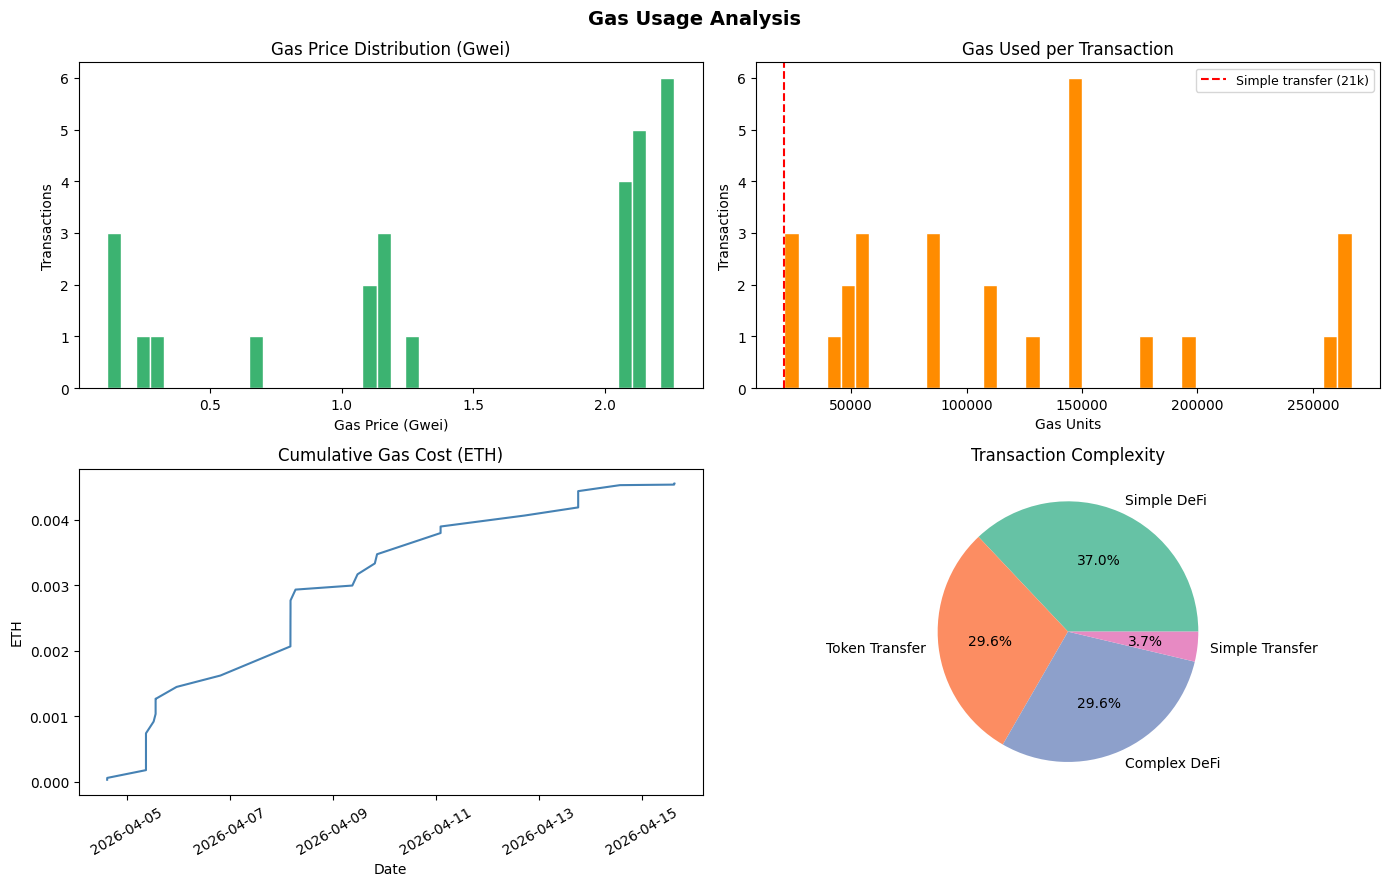


Total ETH spent on gas: 0.004552 ETH


In [26]:
if not tx_df.empty:
    outgoing = tx_df[tx_df["direction"] == "out"].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle("Gas Usage Analysis", fontsize=14, fontweight="bold")

    # ── 1. Gas price distribution ─────────────────────────────────────────────
    axes[0, 0].hist(outgoing["gas_price_gwei"].clip(upper=200),
                    bins=40, color="mediumseagreen", edgecolor="white")
    axes[0, 0].set_title("Gas Price Distribution (Gwei)")
    axes[0, 0].set_xlabel("Gas Price (Gwei)")
    axes[0, 0].set_ylabel("Transactions")

    # ── 2. Gas used per transaction ───────────────────────────────────────────
    axes[0, 1].hist(outgoing["gas_used"].clip(upper=500_000),
                    bins=40, color="darkorange", edgecolor="white")
    axes[0, 1].set_title("Gas Used per Transaction")
    axes[0, 1].set_xlabel("Gas Units")
    axes[0, 1].set_ylabel("Transactions")
    axes[0, 1].axvline(21_000, color="red", linestyle="--", label="Simple transfer (21k)")
    axes[0, 1].legend(fontsize=9)

    # ── 3. Cumulative gas cost over time ──────────────────────────────────────
    outgoing_sorted = outgoing.sort_values("timestamp")
    cumulative_gas  = outgoing_sorted["gas_cost_eth"].cumsum()
    axes[1, 0].plot(outgoing_sorted["timestamp"], cumulative_gas,
                    color="steelblue", linewidth=1.5)
    axes[1, 0].set_title("Cumulative Gas Cost (ETH)")
    axes[1, 0].set_xlabel("Date")
    axes[1, 0].set_ylabel("ETH")
    axes[1, 0].tick_params(axis="x", rotation=30)

    # ── 4. Transaction complexity classification ───────────────────────────────
    def classify_tx(gas: int) -> str:
        if gas <= 21_000:        return "Simple Transfer"
        elif gas <= 65_000:      return "Token Transfer"
        elif gas <= 150_000:     return "Simple DeFi"
        elif gas <= 400_000:     return "Complex DeFi"
        else:                    return "Very Complex"

    outgoing["tx_type"] = outgoing["gas_used"].apply(classify_tx)
    type_counts = outgoing["tx_type"].value_counts()
    axes[1, 1].pie(type_counts, labels=type_counts.index, autopct="%1.1f%%",
                   colors=sns.color_palette("Set2", len(type_counts)))
    axes[1, 1].set_title("Transaction Complexity")

    plt.tight_layout()
    plt.show()

    total_eth_on_gas = outgoing['gas_cost_eth'].sum()
    print(f"\nTotal ETH spent on gas: {total_eth_on_gas:.6f} ETH")

---
## Section 8 — Portfolio Visualisation

Now we pull everything together to build a **visual portfolio report** for any wallet.

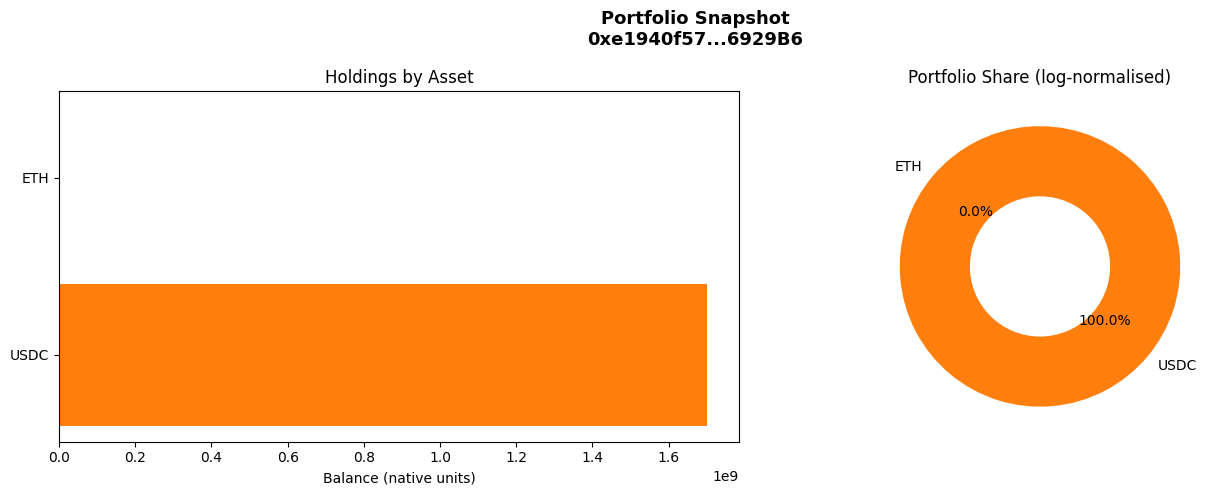


asset      balance                                    address
  ETH 1.000000e-06                                     native
 USDC 1.700000e+09 0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48


In [27]:
def plot_portfolio(wallet: str, tokens: dict = TOKENS) -> None:
    """
    Pull wallet balances and render a portfolio dashboard.
    """
    df = wallet_snapshot(wallet, tokens)
    if df.empty:
        print("Empty portfolio — nothing to visualise.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Portfolio Snapshot\n{wallet[:10]}...{wallet[-6:]}",
                 fontsize=13, fontweight="bold")

    # ── Left: horizontal bar chart ────────────────────────────────────────────
    colors = sns.color_palette("tab10", len(df))
    axes[0].barh(df["asset"], df["balance"], color=colors)
    axes[0].set_xlabel("Balance (native units)")
    axes[0].set_title("Holdings by Asset")
    axes[0].invert_yaxis()

    # ── Right: donut chart (share of holdings) ────────────────────────────────
    # Normalise to percentages — use log scale if values span many orders of magnitude
    import numpy as np
    sizes = df["balance"].values
    log_sizes = np.log1p(sizes)    # log prevents one asset dominating the chart

    wedges, texts, autotexts = axes[1].pie(
        log_sizes,
        labels=df["asset"],
        autopct="%1.1f%%",
        colors=colors,
        wedgeprops={"width": 0.5},   # donut style
        startangle=140,
    )
    axes[1].set_title("Portfolio Share (log-normalised)")

    plt.tight_layout()
    plt.show()

    print("\n" + df.to_string(index=False))


plot_portfolio(WHALE)

---
## Section 9 — Wallet Behavior Scoring
### The DeFi Power-User Index

We can assign a **score** to each wallet based on observable on-chain signals.  
This is how analytics platforms like **Nansen** and **Chainalysis** categorise wallets.

| Signal | Score Points | Reason |
|--------|-------------|--------|
| > 100 transactions | +20 | Active user |
| Holds ≥ 3 DeFi tokens | +20 | Diversified DeFi portfolio |
| Has interacted with contracts | +20 | Not just a simple transfer wallet |
| Low error rate (< 5%) | +20 | Experienced on-chain user |
| Gas spend > 0.05 ETH | +10 | Committed DeFi participant |
| Has Aave activity | +10 | Lending protocol user |

In [28]:
def defi_power_index(wallet: str, tx_history: pd.DataFrame, portfolio: pd.DataFrame) -> dict:
    """
    Compute a DeFi activity score (0–100) for a wallet.
    Higher = more active DeFi power user.
    """
    score    = 0
    signals  = {}

    # ── Signal 1: transaction volume ─────────────────────────────────────────
    tx_count = len(tx_history)
    if tx_count > 100:
        score += 20
        signals["High tx volume"] = f"{tx_count} txns (+20)"
    elif tx_count > 10:
        score += 10
        signals["Moderate tx volume"] = f"{tx_count} txns (+10)"

    # ── Signal 2: token diversity ─────────────────────────────────────────────
    defi_tokens_held = portfolio[portfolio["asset"].isin(["UNI", "AAVE", "LINK", "WETH", "DAI"])]
    n_defi = len(defi_tokens_held)
    if n_defi >= 3:
        score += 20
        signals["DeFi token diversity"] = f"{n_defi} DeFi tokens (+20)"
    elif n_defi >= 1:
        score += 10
        signals["Some DeFi tokens"] = f"{n_defi} DeFi tokens (+10)"

    # ── Signal 3: contract interactions ──────────────────────────────────────
    if not tx_history.empty and "functionName" in tx_history.columns:
        contract_txns = tx_history[tx_history["functionName"].notna() &
                                   (tx_history["functionName"] != "")]
        pct_contract  = len(contract_txns) / max(len(tx_history), 1)
        if pct_contract > 0.3:
            score += 20
            signals["Contract interactions"] = f"{pct_contract:.0%} of txns (+20)"
        elif pct_contract > 0:
            score += 10
            signals["Some contract interactions"] = f"{pct_contract:.0%} of txns (+10)"

    # ── Signal 4: low error rate ──────────────────────────────────────────────
    if not tx_history.empty and "is_error" in tx_history.columns:
        error_rate = tx_history["is_error"].mean()
        if error_rate < 0.05:
            score += 20
            signals["Low error rate"] = f"{error_rate:.1%} (+20)"

    # ── Signal 5: gas commitment ──────────────────────────────────────────────
    if not tx_history.empty and "gas_cost_eth" in tx_history.columns:
        outgoing = tx_history[tx_history["direction"] == "out"]
        total_gas = outgoing["gas_cost_eth"].sum()
        if total_gas > 0.05:
            score += 10
            signals["Significant gas spend"] = f"{total_gas:.4f} ETH (+10)"

    return {
        "wallet" : wallet,
        "score"  : min(score, 100),
        "signals": signals,
        "label"  : (
            "DeFi Power User"   if score >= 70 else
            "Active DeFi User"  if score >= 40 else
            "Casual User"       if score >= 20 else
            "Newcomer / Inactive"
        )
    }

print("Scoring function ready.")

Scoring function ready.


In [29]:
# ── Score the study wallet ────────────────────────────────────────────────────
portfolio_df = wallet_snapshot(STUDY_WALLET)
result = defi_power_index(STUDY_WALLET, tx_df, portfolio_df)

print("=" * 50)
print(f"  Wallet  : {result['wallet'][:14]}...")
print(f"  Score   : {result['score']} / 100")
print(f"  Label   : {result['label']}")
print("  Signals :")
for sig, detail in result["signals"].items():
    print(f"    ✓  {sig}: {detail}")
print("=" * 50)

  Wallet  : 0x7B9eB6Dc28dE...
  Score   : 50 / 100
  Label   : Active DeFi User
  Signals :
    ✓  Moderate tx volume: 35 txns (+10)
    ✓  Contract interactions: 60% of txns (+20)
    ✓  Low error rate: 0.0% (+20)


        name         address  score            label
Study Wallet 0xE1fC783485...     40 Active DeFi User
 Binance Hot 0xe1940f5787...     20      Casual User


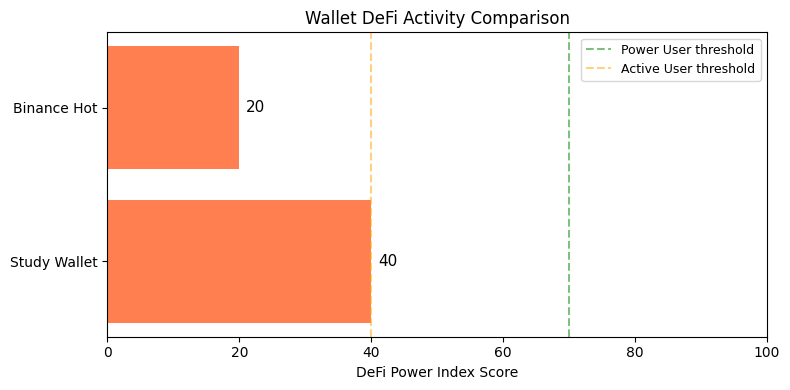

In [30]:
# ── Score multiple wallets and compare ────────────────────────────────────────
WALLETS_TO_COMPARE = [
    ("Study Wallet",   "0xE1fC7834857Ece72e1CBaaa227Cf038AE9168267"),
    ("Binance Hot",    "0xe1940f578743367F38D3f25c2D2d32D6636929B6"),
]

scores = []
for label, addr in WALLETS_TO_COMPARE:
    port = wallet_snapshot(addr)
    hist = fetch_tx_history(addr, max_records=50) if ETHERSCAN_KEY else pd.DataFrame()
    res  = defi_power_index(addr, hist, port)
    scores.append({"name": label, "address": addr[:12] + "...", "score": res["score"], "label": res["label"]})

scores_df = pd.DataFrame(scores)
print(scores_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(scores_df["name"], scores_df["score"],
               color=["steelblue" if s >= 70 else "coral" for s in scores_df["score"]])
ax.set_xlim(0, 100)
ax.set_xlabel("DeFi Power Index Score")
ax.set_title("Wallet DeFi Activity Comparison")
ax.axvline(70, color="green", linestyle="--", alpha=0.5, label="Power User threshold")
ax.axvline(40, color="orange", linestyle="--", alpha=0.5, label="Active User threshold")
ax.legend(fontsize=9)
for bar, score in zip(bars, scores_df["score"]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(score), va="center", fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 10 — Putting It All Together: Full Wallet Report

This is the capstone function — it runs the full analysis pipeline for any address.


  FULL DEFI WALLET REPORT
  Address : 0x7B9eB6Dc28dE8b81189067f04458E2F723a0dB01
  Date    : 2026-04-15 15:38 UTC

[1/4] Portfolio Snapshot...


/tmp/ipykernel_239939/321561379.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  print(f"  Date    : {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}")


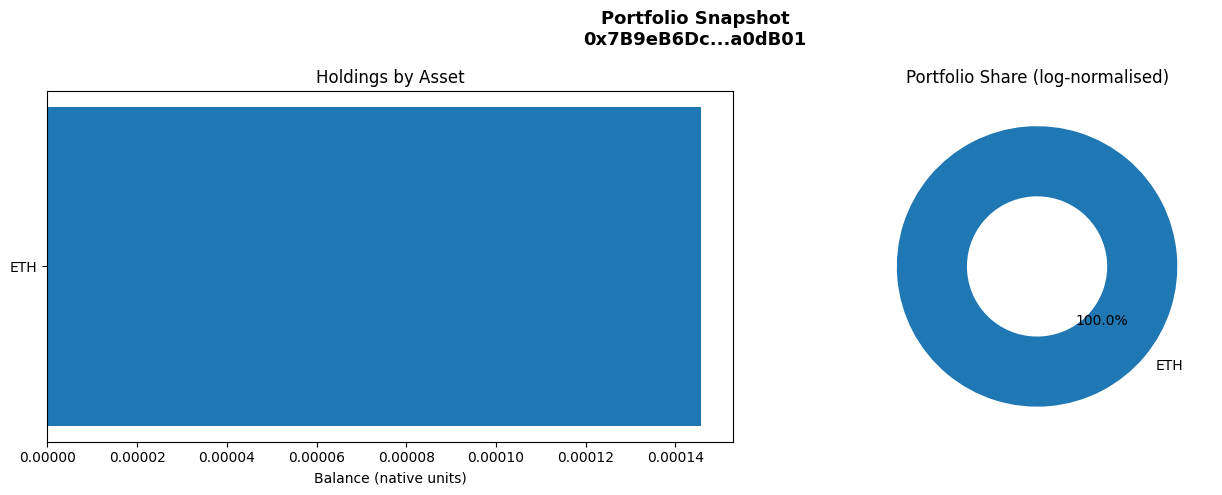


asset  balance address
  ETH 0.000146  native

[2/4] Transaction History...
    36 txns fetched | 28 outgoing | 0 failed

[3/4] Recent USDC Transfers...
No USDC transfers found in the specified block range.

[4/4] DeFi Power-User Score...
    Score : 50 / 100  →  Active DeFi User
      + Moderate tx volume: 36 txns (+10)
      + Contract interactions: 61% of txns (+20)
      + Low error rate: 0.0% (+20)

  Report complete.


In [31]:
def full_wallet_report(wallet: str, blocks_back: int = 5_000) -> None:
    """
    Run the complete DeFi analysis pipeline for a given wallet address.
    Prints a summary report and renders visualisations.
    """
    print("\n" + "=" * 60)
    print(f"  FULL DEFI WALLET REPORT")
    print(f"  Address : {wallet}")
    print(f"  Date    : {datetime.utcnow().strftime('%Y-%m-%d %H:%M UTC')}")
    print("=" * 60)

    # 1. Current balances
    print("\n[1/4] Portfolio Snapshot...")
    portfolio = wallet_snapshot(wallet)
    plot_portfolio(wallet)

    # 2. Transaction history
    print("\n[2/4] Transaction History...")
    tx_history = fetch_tx_history(wallet, max_records=100)
    if not tx_history.empty:
        out = tx_history[tx_history["direction"] == "out"]
        print(f"    {len(tx_history)} txns fetched | {len(out)} outgoing | "
              f"{tx_history['is_error'].sum()} failed")

    # 3. Recent USDC transfers
    print("\n[3/4] Recent USDC Transfers...")
    latest = w3.eth.block_number
    usdc_tx = get_token_transfers(wallet, TOKENS["USDC"],
                                   from_block=latest - blocks_back)
    if not usdc_tx.empty:
        print(f"    Found {len(usdc_tx)} USDC transfer(s) in last {blocks_back:,} blocks")
        total_in  = usdc_tx[usdc_tx["direction"] == "in" ]["value"].sum()
        total_out = usdc_tx[usdc_tx["direction"] == "out"]["value"].sum()
        print(f"    Received: {total_in:,.2f} USDC | Sent: {total_out:,.2f} USDC")

    # 4. Behavior score
    print("\n[4/4] DeFi Power-User Score...")
    result = defi_power_index(wallet, tx_history, portfolio)
    print(f"    Score : {result['score']} / 100  →  {result['label']}")
    for sig, detail in result["signals"].items():
        print(f"      + {sig}: {detail}")

    print("\n" + "=" * 60)
    print("  Report complete.")
    print("=" * 60)


# ── Run the report ────────────────────────────────────────────────────────────
full_wallet_report(STUDY_WALLET)

---
## Key Concepts Summary

| Concept | What It Is | Python Tool |
|---------|-----------|-------------|
| **ERC-20 `balanceOf`** | Read token balance from a smart contract | `w3.eth.contract().functions.balanceOf().call()` |
| **`eth_getLogs`** | Query event logs by address, topic, block range | `w3.eth.get_logs({...})` |
| **Transfer topic** | keccak256 hash of event signature — used to filter logs | `w3.keccak(text="Transfer(address,address,uint256)")` |
| **Uniswap V2 Swap** | AMM swap event emitted by pair contracts | Filter logs on `Swap` topic |
| **Aave Deposit/Borrow** | Lending protocol events on LendingPool | Filter logs on `Deposit` / `Borrow` topic |
| **Gas analysis** | Understanding cost & complexity of transactions | Etherscan API + pandas |
| **Wallet scoring** | Classify wallets by on-chain behaviour signals | Custom logic on fetched data |

---
## Further Challenges

1. **Compound Finance** — Fetch `Mint` and `Borrow` events from cToken contracts (`0x5d3a536E4D6DbD6114cc1Ead35777bAB948E3643` for cDAI)
2. **MEV Detection** — Identify sandwich attacks: find swaps where the same address appears in the transaction before and after a large swap in the same block
3. **Liquidation Tracker** — Parse Aave `LiquidationCall` events to find wallets being liquidated (great for risk analysis)
4. **Multi-Wallet Dashboard** — Accept a list of wallets (e.g. a DAO's treasury multi-sig signers) and produce a comparative dashboard
5. **Historical Price Feed** — Derive ETH/USD price from Uniswap V2 swaps over many blocks and plot it against the official CoinGecko API